# 📈 Linear Regression — Hotel Price Prediction

Train a Linear Regression model on the preprocessed Indian hotel pricing data.

**Prerequisites**: Run `01_data_exploration.ipynb` first to generate the preprocessed data.

---

## 1. Setup

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Preprocessed Data

In [3]:
# Load train/test data from the EDA notebook
data = np.load('models/train_test_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Load feature names saved by notebook 01
feature_names = joblib.load('models/feature_names.pkl')

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')
print(f'Features:         {X_train.shape[1]}')
print(f'Feature names:    {feature_names}')

Training samples: 464
Test samples:     116
Features:         8
Feature names:    ['Rating', 'Reviews', 'Star Rating', 'City', 'Rating Desc', 'Has Landmark', 'Distance km', 'Tax']


## 3. Train Linear Regression

In [4]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('✅ Linear Regression trained successfully')
print(f'\nCoefficients: {lr_model.coef_}')
print(f'Intercept: {lr_model.intercept_:.2f}')

✅ Linear Regression trained successfully

Coefficients: [  776.51428914  -131.02541775  1917.31065724   372.14265999
 -1275.89541622  -416.71523981   316.82578375   592.52728192]
Intercept: 5197.43


## 4. Evaluate Model

In [5]:
# Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Metrics
train_metrics = {
    'MAE': mean_absolute_error(y_train, y_train_pred),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
    'R² Score': r2_score(y_train, y_train_pred)
}

test_metrics = {
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'R² Score': r2_score(y_test, y_test_pred)
}

print('📊 Training Metrics:')
for k, v in train_metrics.items():
    print(f'   {k}: {v:.4f}')

print('\n📊 Test Metrics:')
for k, v in test_metrics.items():
    print(f'   {k}: {v:.4f}')

📊 Training Metrics:
   MAE: 2215.4299
   RMSE: 6182.3951
   R² Score: 0.1976

📊 Test Metrics:
   MAE: 2034.4880
   RMSE: 2597.2703
   R² Score: 0.3178


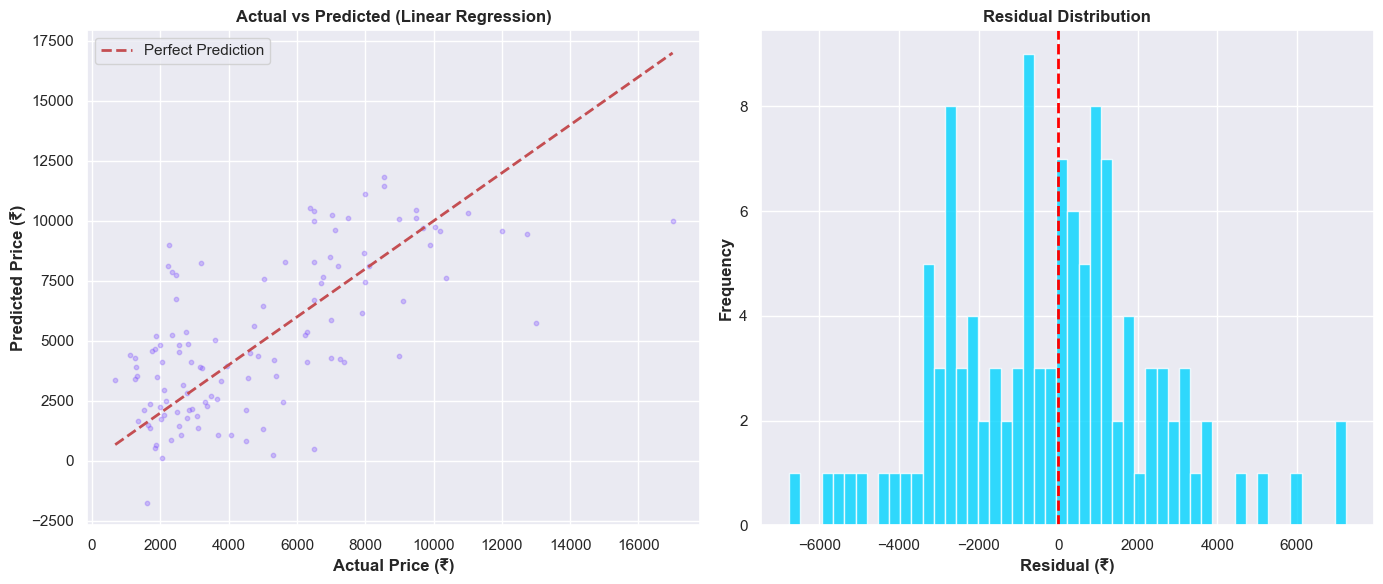

In [6]:
# Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test, y_test_pred, alpha=0.3, c='#7c4dff', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₹)', fontweight='bold')
axes[0].set_ylabel('Predicted Price (₹)', fontweight='bold')
axes[0].set_title('Actual vs Predicted (Linear Regression)', fontweight='bold')
axes[0].legend()

# Residual distribution
residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=50, color='#00d4ff', alpha=0.8, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (₹)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

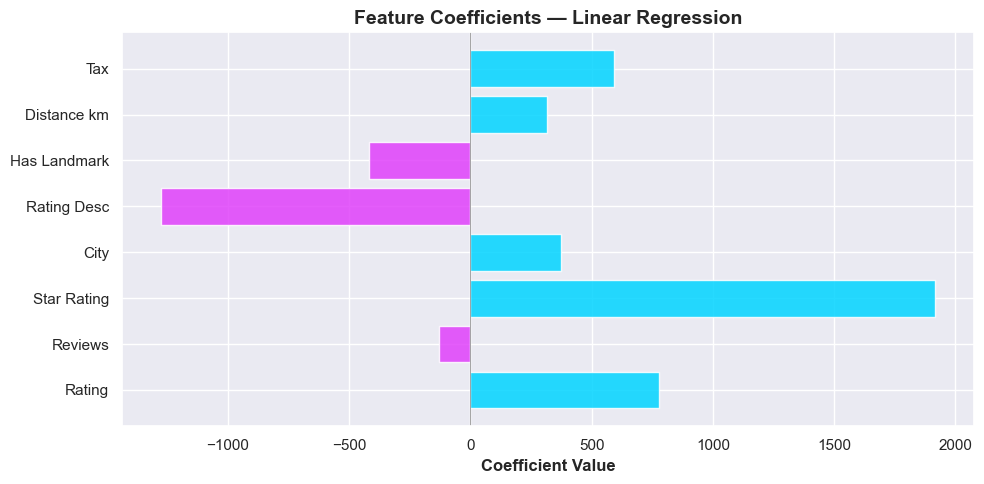

In [7]:
# Feature Importance (coefficients)
coefs = lr_model.coef_

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#00d4ff' if c >= 0 else '#e040fb' for c in coefs]
bars = ax.barh(feature_names, coefs, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Coefficient Value', fontweight='bold')
ax.set_title('Feature Coefficients — Linear Regression', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='-', lw=0.5)
plt.tight_layout()
plt.show()

## 5. Save Model

In [8]:
os.makedirs('models', exist_ok=True)
model_path = 'models/linear_regression.pkl'
joblib.dump(lr_model, model_path)

print(f'✅ Model saved to: {model_path}')
print(f'   File size: {os.path.getsize(model_path) / 1024:.1f} KB')
print(f'\n📊 Final Test R² Score: {test_metrics["R² Score"]:.4f}')

✅ Model saved to: models/linear_regression.pkl
   File size: 0.7 KB

📊 Final Test R² Score: 0.3178


In [9]:
print('\n🎉 Linear Regression Training Complete!')
print('\nNext: Run 03_random_forest.ipynb')


🎉 Linear Regression Training Complete!

Next: Run 03_random_forest.ipynb
